## covered concepts
 - python programming
 - data analysis module
 - ml-classification(SVM,Decision tree,Logistic,Bagging,boosting)
 - ml-regression(linear,poly,ridge,lasso)

## Supervised learning:
 - It is a process of giving labelled data to the machine and predicting the output
 - have labels
 - predicts value(output)

## Unsupervised learning:
 - It is a process of giving unlabelled data to the machine and predicting groups or patterns
 - doesnot have labels
 - predicts patterns or groups

 


In [2]:
# similarity
import numpy as np
from numpy.linalg import norm
A = np.array([170,65])
B = np.array([172,67])
C = np.array([193,96])
print(norm(A-B))
print(norm(A-C))

2.8284271247461903
38.600518131237564


# Clustering:
- cluster is a group of similar elements, no labels, no prediction, only grouping
## Types of cluster:
1. Centroid based cluster(k-means)
2. Tree based cluster(hierarchical)
 --- Agglomerative clustering
3. Density based cluster
 --- DBSCAN
 --- GVM

## k-means
- k means groups data points into k clusters such that all points in the same cluster are as similar as possible
- who suppose to give k value? Customer or business owner
- k(no.of clusters)   means(avg)
- Scaling is mandatory for k means because we are working on distance
- it is outlier sensitive

### How k-means algorithm works
1. Choose k value
2. Place k random centroids(temporary centroid points)
3. Assign points to nearest centroids
4. Recalculate centroids(mean value)
5. Repeat 3 and 4 until centroid points stop moving



In [9]:
import pandas as pd
data = {
    'Annual_Income': [15,18,30,35,35,40,50,55,65,70],
    'Spending_Score': [39,81,6,77,72,94,13,56,92,17]
}
data = pd.DataFrame(data)
data

,Annual_Income,Spending_Score
0,15,39
1,18,81
2,30,6
3,35,77
4,35,72
5,40,94
6,50,13
7,55,56
8,65,92
9,70,17


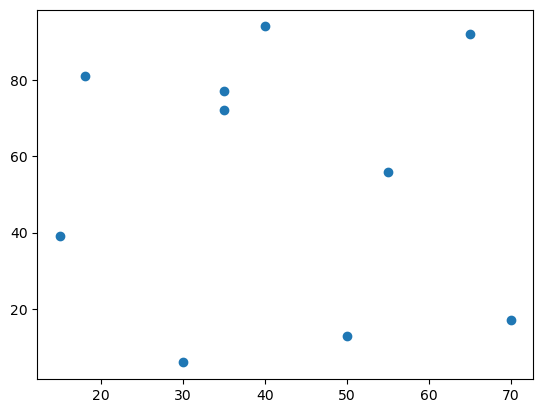

In [10]:
# Visualize the data befor k-means
import matplotlib.pyplot as plt
plt.scatter(data['Annual_Income'], data['Spending_Score'])


In [11]:
# Create k-means model and train the data
from sklearn.cluster import KMeans
model = KMeans(n_clusters=2)
model.fit(data)


c:\Users\MADHU\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [12]:
data['groups'] = model.labels_
data

,Annual_Income,Spending_Score,groups
0,15,39,0
1,18,81,1
2,30,6,0
3,35,77,1
4,35,72,1
5,40,94,1
6,50,13,0
7,55,56,1
8,65,92,1
9,70,17,0


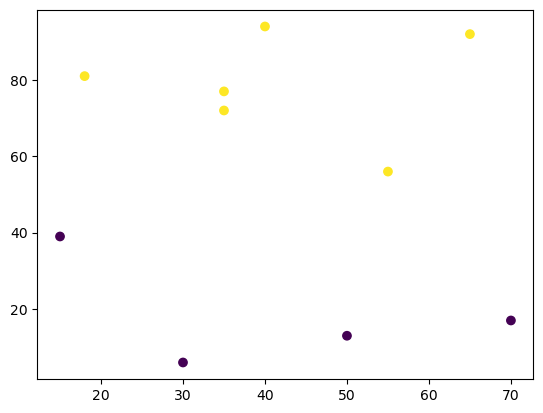

In [13]:
plt.scatter(data['Annual_Income'], data['Spending_Score'], c=data['groups'])

### Inertia(checks quality of cluster-if the points in the centroids are closer together): 
- calculates distance between each and every point to the centroid and gives squared value
- total distance of all points from their respective cluster centroids
- it measures how compact the clusters are
- it checks the clusters are good or bad

inertia=0(when data points= clusters)

In [14]:
# Inertia
model.inertia_

4680.166666666666

In [15]:
# Silhouette score
from sklearn.metrics import silhouette_score
score = silhouette_score(data, model.labels_)
print(score)

0.4924636902508427


# Real time projects on kmeans
1. Customer segmentation for e commerce website
2. Movie recommendation cluster
3. Smart phone usage segmentation (clusters-data users,calls users,low users)
4. Patient risk segmentation (BP,Sugar,....:clusters-high risk,medium risk,low risk)
5. Product grouping segmentation (premium,budget)
6. Fraud detection(normal behaviour,suspicious)
7. Student performance(toppers,avgstudents,risk students)
